In [1]:
!pip install pydicom opencv-python tqdm


In [2]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


In [30]:
BASE_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"
DICOM_PATH = os.path.join(BASE_PATH, "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train")
CSV_PATH = os.path.join(BASE_PATH, "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv")

OUTPUT_IMAGE_PATH = "/kaggle/working/images"
OUTPUT_LABEL_PATH = "/kaggle/working/labels"

os.makedirs(OUTPUT_IMAGE_PATH, exist_ok=True)
os.makedirs(OUTPUT_LABEL_PATH, exist_ok=True)


In [31]:
os.listdir(BASE_PATH)  #To check the datasets in BASE_PATH


['sample_submission.csv', 'train.csv', 'test', 'train']

In [ ]:
def dicom_to_png(dicom_path, output_path, limit=1000):
    files = os.listdir(dicom_path)
    count = 0
    
    for file in tqdm(files):
        if file.endswith(".dicom") or file.endswith(".dcm"):    #Convert first 200 images to PNG format out of 15000 images
            
            if count >= limit:   # Hard stop condition
                break
            
            full_path = os.path.join(dicom_path, file)
            
            try:
                dcm = pydicom.dcmread(full_path)
                img = dcm.pixel_array
                
                # Normalize safely
                img = img - np.min(img)
                if np.max(img) != 0:
                    img = img / np.max(img)
                
                img = (img * 255).astype(np.uint8)
                
                output_file = file.replace(".dicom", ".png").replace(".dcm", ".png")
                cv2.imwrite(os.path.join(output_path, output_file), img)
                
                count += 1
            
            except Exception as e:
                print(f"Error with {file}: {e}")

    print(f"Total converted: {count}")

dicom_to_png(DICOM_PATH, OUTPUT_IMAGE_PATH, limit=1000)

Converted sample image


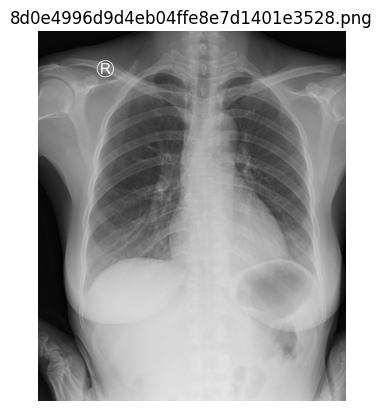

In [49]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[0]
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img), 0)

plt.imshow(img, cmap='gray')
plt.title(sample_img)
plt.axis("off")
print("Converted sample image")
plt.show()


In [50]:
df = pd.read_csv(CSV_PATH)
df.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [51]:
classes = df['class_name'].unique()
class_dict = {name: i for i, name in enumerate(classes)}

print(class_dict)


{'No finding': 0, 'Cardiomegaly': 1, 'Aortic enlargement': 2, 'Pleural thickening': 3, 'ILD': 4, 'Nodule/Mass': 5, 'Pulmonary fibrosis': 6, 'Lung Opacity': 7, 'Atelectasis': 8, 'Other lesion': 9, 'Infiltration': 10, 'Pleural effusion': 11, 'Calcification': 12, 'Consolidation': 13, 'Pneumothorax': 14}


In [55]:
grouped = df.groupby("image_id")

for image_id, group in tqdm(grouped):
    
    img_file = os.path.join(OUTPUT_IMAGE_PATH, image_id + ".png")
    
    if not os.path.exists(img_file):
        continue
    
    img = cv2.imread(img_file)
    h, w, _ = img.shape
    
    label_file = os.path.join(OUTPUT_LABEL_PATH, image_id + ".txt")
    
    with open(label_file, "w") as f:
        for _, row in group.iterrows():
            
            # 🚨 Skip No Finding (NaN boxes)
            if pd.isna(row.x_min):
                continue
            
            x_center = ((row.x_min + row.x_max) / 2) / w
            y_center = ((row.y_min + row.y_max) / 2) / h
            width = (row.x_max - row.x_min) / w
            height = (row.y_max - row.y_min) / h
            
            class_id = class_dict[row.class_name]
            
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


100%|██████████| 15000/15000 [00:16<00:00, 917.77it/s] 


In [56]:
sample_label = os.listdir(OUTPUT_LABEL_PATH)[0]

with open(os.path.join(OUTPUT_LABEL_PATH, sample_label)) as f:
    print(f.read())


10 0.322265625 0.4388020833333333 0.20833333333333334 0.17447916666666666
2 0.55615234375 0.2578125 0.08365885416666667 0.10286458333333333
4 0.3045247395833333 0.4410807291666667 0.0908203125 0.11653645833333333
2 0.56201171875 0.24186197916666666 0.06477864583333333 0.07552083333333333
2 0.5564778645833334 0.26318359375 0.08756510416666667 0.1123046875
4 0.322265625 0.4388020833333333 0.20833333333333334 0.17447916666666666
1 0.5524088541666666 0.5105794270833334 0.31640625 0.11360677083333333



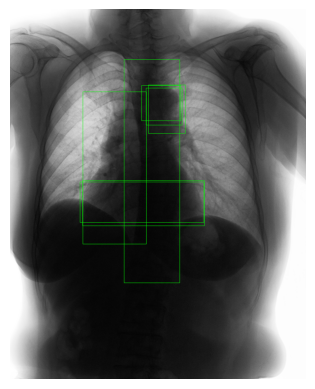

In [69]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[4]  
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img))

h, w, _ = img.shape            #To check if any abnormalities found in the image the bounding box correctly displays it

label_path = os.path.join(OUTPUT_LABEL_PATH, sample_img.replace(".png", ".txt"))

if os.path.exists(label_path):
    with open(label_path) as f:
        lines = f.readlines()
        
    for line in lines:
        class_id, xc, yc, bw, bh = map(float, line.split())
        
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
